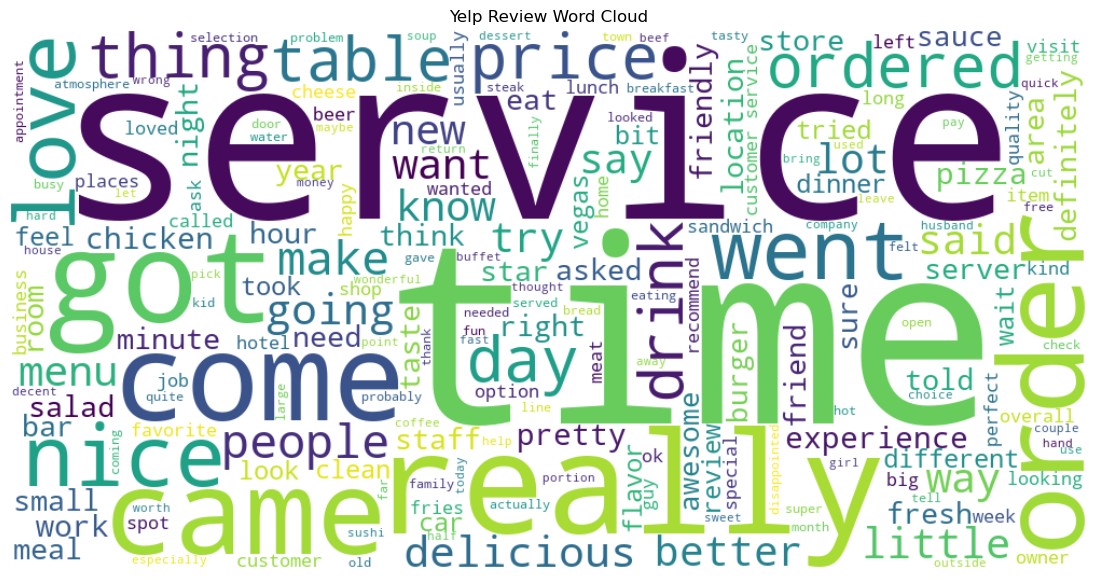

In this visualization, I examined the most frequently used words in Yelp reviews to better understand what customers emphasize in their feedback. I observed that words such as “service,” “time,” and “food” appear most prominently, which suggests that customers focus heavily on service quality and overall dining experience. Based on what I see in the word cloud, these themes seem to strongly influence how people describe restaurants in their reviews.

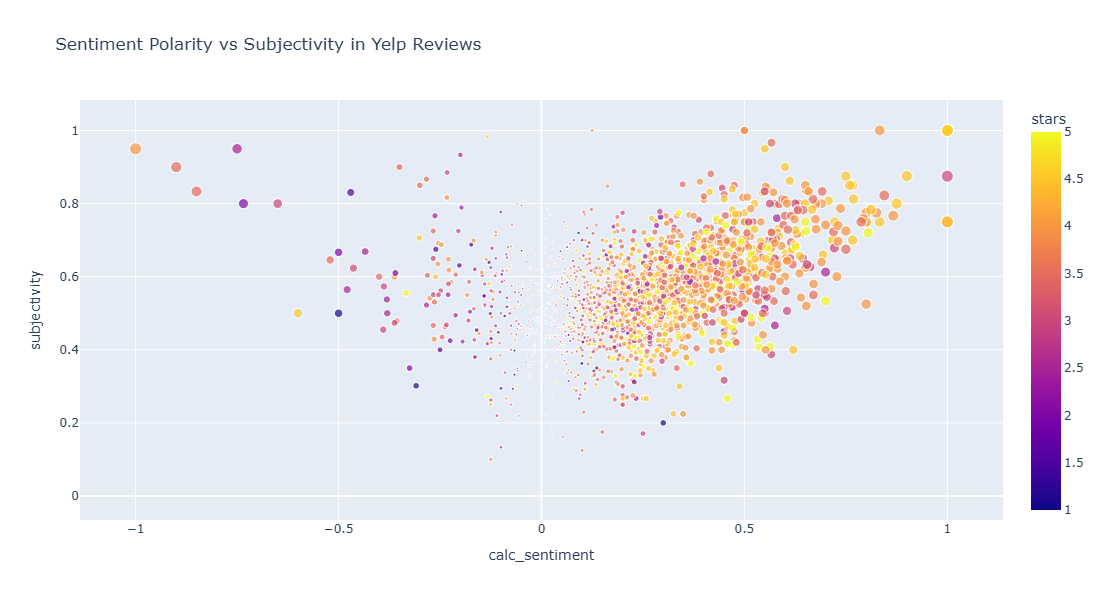

In [5]:
import pandas as pd
import plotly.express as px
from textblob import TextBlob
import warnings

warnings.filterwarnings("ignore")

# Load Yelp dataset
df = pd.read_csv(r"C:\Users\hudso\OneDrive\Desktop\Data_Visualization_And_Modeling_Online-main\Data_Visualization_And_Modeling_Online-main\Lab\yelp_subset.csv")

# Compute sentiment polarity and subjectivity from review text
df['calc_sentiment'] = df['text'].astype(str).apply(lambda x: TextBlob(x).sentiment.polarity)
df['subjectivity'] = df['text'].astype(str).apply(lambda x: TextBlob(x).sentiment.subjectivity)
df['abs_sentiment'] = df['calc_sentiment'].abs()

# Create scatter plot
fig = px.scatter(
    df,
    x='calc_sentiment',
    y='subjectivity',
    color='stars',
    size='abs_sentiment',
    size_max=12,
    hover_data=['text'],
    title='Sentiment Polarity vs Subjectivity in Yelp Reviews'
)

fig.update_layout(height=600)
fig.show()

When I examined this figure, I immediately noticed a clear pattern between sentiment polarity and star ratings. I found that higher-rated reviews tend to cluster on the positive side of the sentiment scale, while lower-rated reviews are more concentrated in the negative range. As I looked more closely, I saw that most reviews fall within moderate to high subjectivity levels, which tells me that customers are primarily expressing personal opinions rather than objective descriptions. What stood out to me is how closely the calculated sentiment aligns with the assigned star ratings, even though there is some overlap between categories. From this analysis, I learned that sentiment scoring provides a strong quantitative reflection of how customers perceive their dining experiences.

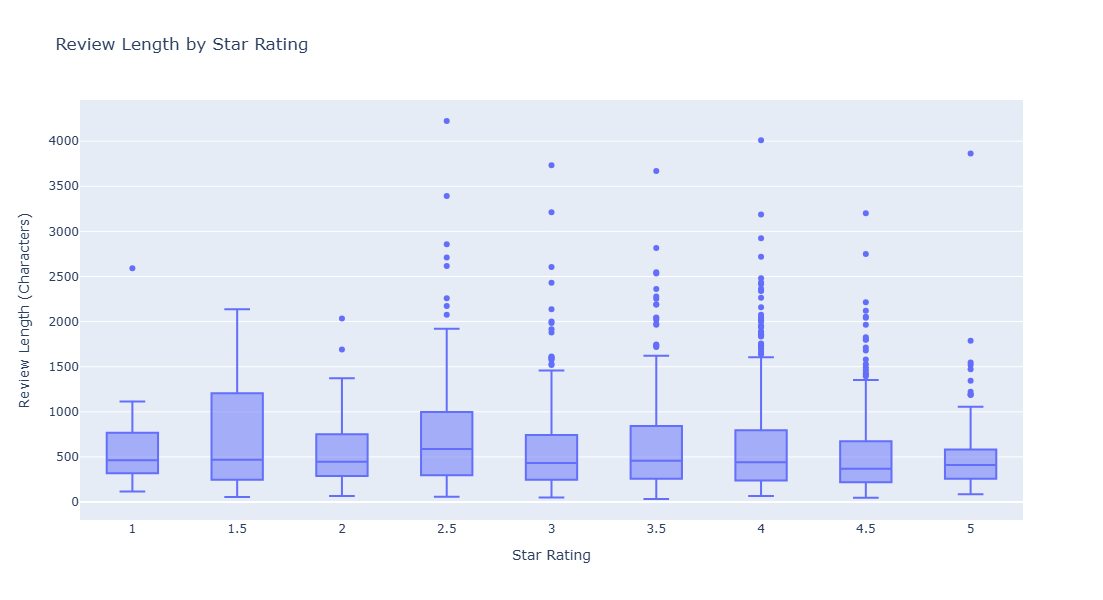

In [8]:
import pandas as pd
import plotly.express as px

# Load Yelp dataset
df = pd.read_csv(r"C:\Users\hudso\OneDrive\Desktop\Data_Visualization_And_Modeling_Online-main\Data_Visualization_And_Modeling_Online-main\Lab\yelp_subset.csv")

# Create review length column
df['review_length'] = df['text'].astype(str).str.len()

# Create box plot of review length by star rating
fig = px.box(
    df,
    x='stars',
    y='review_length',
    title='Review Length by Star Rating',
    labels={'stars': 'Star Rating', 'review_length': 'Review Length (Characters)'}
)

fig.update_layout(height=600)
fig.show()

As I reviewed this chart, I concentrated on how review length varies across different star ratings. I observed that lower and mid-range ratings display a wider spread in review length, with several noticeable outliers in those groups. After looking at the median lines within each box, I realized that review length does not steadily increase with higher ratings, which suggests that longer reviews are not automatically associated with more positive experiences. What caught my attention is that some of the longest reviews appear in both lower and mid-level ratings, which makes sense because dissatisfied customers often provide detailed explanations of their experiences. From this analysis, I concluded that review length alone does not determine sentiment, but it does reflect the intensity or depth of a reviewer’s response.